In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/4
    print("準備完了！このまま下のセルを実行できます。")

# 4.2 生成モデル (Probabilistic Generative Models)

本ノートブックでは、クラス条件付き確率密度 $p(\mathbf{x} | \mathcal{C}_k)$ とクラス事前確率 $p(\mathcal{C}_k)$ をモデル化し、ベイズの定理によってクラス事後確率 $p(\mathcal{C}_k | \mathbf{x})$ を求める**確率的生成モデル (Probabilistic Generative Models)** を扱います。
ガウス分布仮定からロジスティックシグモイドおよびソフトマックス関数が必然的に導出される理論的背景、線形判別分析 (LDA) と二次判別分析 (QDA) の最尤推定解、および**PRML Figure 4.9, 4.10, 4.11** の完全再現を行います。

## 4.2.1 連続入力とシグモイド／ソフトマックスの必然的導出

### 2クラスの場合
ベイズの定理より、クラス $\mathcal{C}_1$ の事後確率は
$$ p(\mathcal{C}_1 | \mathbf{x}) = \frac{p(\mathbf{x} | \mathcal{C}_1) p(\mathcal{C}_1)}{p(\mathbf{x} | \mathcal{C}_1) p(\mathcal{C}_1) + p(\mathbf{x} | \mathcal{C}_2) p(\mathcal{C}_2)} = \frac{1}{1 + \exp(-a)} = \sigma(a) $$
ここで
$$ a = \ln \frac{p(\mathbf{x} | \mathcal{C}_1) p(\mathcal{C}_1)}{p(\mathbf{x} | \mathcal{C}_2) p(\mathcal{C}_2)} = \ln \frac{p(\mathbf{x} | \mathcal{C}_1)}{p(\mathbf{x} | \mathcal{C}_2)} + \ln \frac{p(\mathcal{C}_1)}{p(\mathcal{C}_2)} $$
は**対数オッズ比 (log-odds / logit)** です。
ロジスティックシグモイド関数 $\sigma(a) = \frac{1}{1 + e^{-a}}$ は単なるヒューリスティックではなく、**2つの確率の比から必然的に現れる数学的表現**です。

### ガウス仮定による線形識別関数 (LDA)
クラス条件付き分布が共通の共分散行列 $\mathbf{\Sigma}$ を持つ多変量正規分布であると仮定します：
$$ p(\mathbf{x} | \mathcal{C}_k) = \frac{1}{(2\pi)^{D/2} |\mathbf{\Sigma}|^{1/2}} \exp\left( -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu}_k)^T \mathbf{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}_k) \right) $$
これを対数オッズ比 $a(\mathbf{x})$ に代入すると、$\mathbf{x}^T \mathbf{\Sigma}^{-1} \mathbf{x}$ の二次項が完全に相殺し、厳密に**線形関数**となります：
$$ a(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + w_0 $$
ここで
$$ \mathbf{w} = \mathbf{\Sigma}^{-1} (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2) $$
$$ w_0 = -\frac{1}{2} \boldsymbol{\mu}_1^T \mathbf{\Sigma}^{-1} \boldsymbol{\mu}_1 + \frac{1}{2} \boldsymbol{\mu}_2^T \mathbf{\Sigma}^{-1} \boldsymbol{\mu}_2 + \ln \frac{p(\mathcal{C}_1)}{p(\mathcal{C}_2)} $$

### 多クラスの場合 (ソフトマックス関数)
$K > 2$ クラスの場合、
$$ p(\mathcal{C}_k | \mathbf{x}) = \frac{p(\mathbf{x} | \mathcal{C}_k) p(\mathcal{C}_k)}{\sum_j p(\mathbf{x} | \mathcal{C}_j) p(\mathcal{C}_j)} = \frac{\exp(a_k)}{\sum_j \exp(a_j)} = \mathrm{softmax}(a_1, \dots, a_K) $$
ここで $a_k = \ln [p(\mathbf{x} | \mathcal{C}_k) p(\mathcal{C}_k)] = \mathbf{w}_k^T \mathbf{x} + w_{k0}$ となり、これもまた線形関数となります。

Plot saved to: result/fig4_9_logistic_sigmoid.png


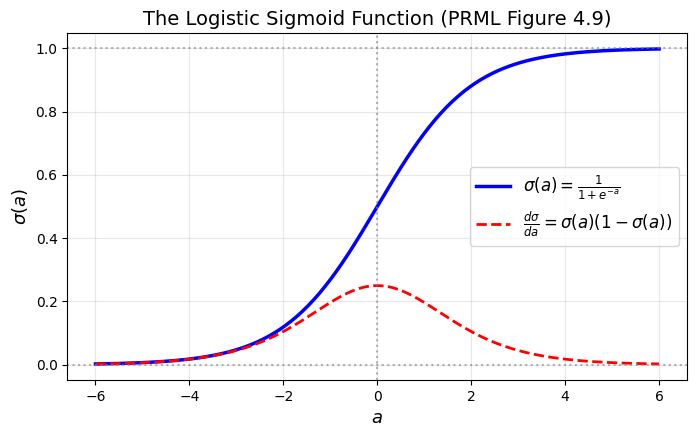

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.classification_utils import sigmoid, GaussianGenerativeClassifier
setup_style()

# PRML Figure 4.9: ロジスティックシグモイド関数と導関数
a = np.linspace(-6, 6, 200)
sig = sigmoid(a)
dsig = sig * (1.0 - sig)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(a, sig, 'b-', lw=2.5, label=r'$\sigma(a) = \frac{1}{1 + e^{-a}}$')
ax.plot(a, dsig, 'r--', lw=2.0, label=r'$\frac{d\sigma}{da} = \sigma(a)(1 - \sigma(a))$')

ax.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax.axhline(1, color='gray', linestyle=':', alpha=0.6)
ax.axvline(0, color='gray', linestyle=':', alpha=0.6)
ax.set_title('The Logistic Sigmoid Function (PRML Figure 4.9)', fontsize=14)
ax.set_xlabel('$a$', fontsize=13)
ax.set_ylabel('$\sigma(a)$', fontsize=13)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

save_plot(fig, 'result', 'fig4_9_logistic_sigmoid.png')
plt.show()

## 4.2.2 線形判別 (LDA) と二次判別 (QDA) の幾何学 (PRML Figure 4.10 & 4.11)

- **線形判別分析 (LDA / 共通共分散 $\mathbf{\Sigma}_1 = \mathbf{\Sigma}_2 = \mathbf{\Sigma}$)**:
  二次項が相殺するため、決定境界は直線（超平面）となり、事後確率はシグモイド曲面を描きます（PRML Figure 4.10）。
- **二次判別分析 (QDA / 個別共分散 $\mathbf{\Sigma}_1 \neq \mathbf{\Sigma}_2$)**:
  二次項 $\mathbf{x}^T (\mathbf{\Sigma}_1^{-1} - \mathbf{\Sigma}_2^{-1}) \mathbf{x}$ が相殺せず残り、決定境界は**二次曲線（楕円・放物線・双曲線）**となります（PRML Figure 4.11）。

Plot saved to: result/fig4_10_11_lda_qda.png


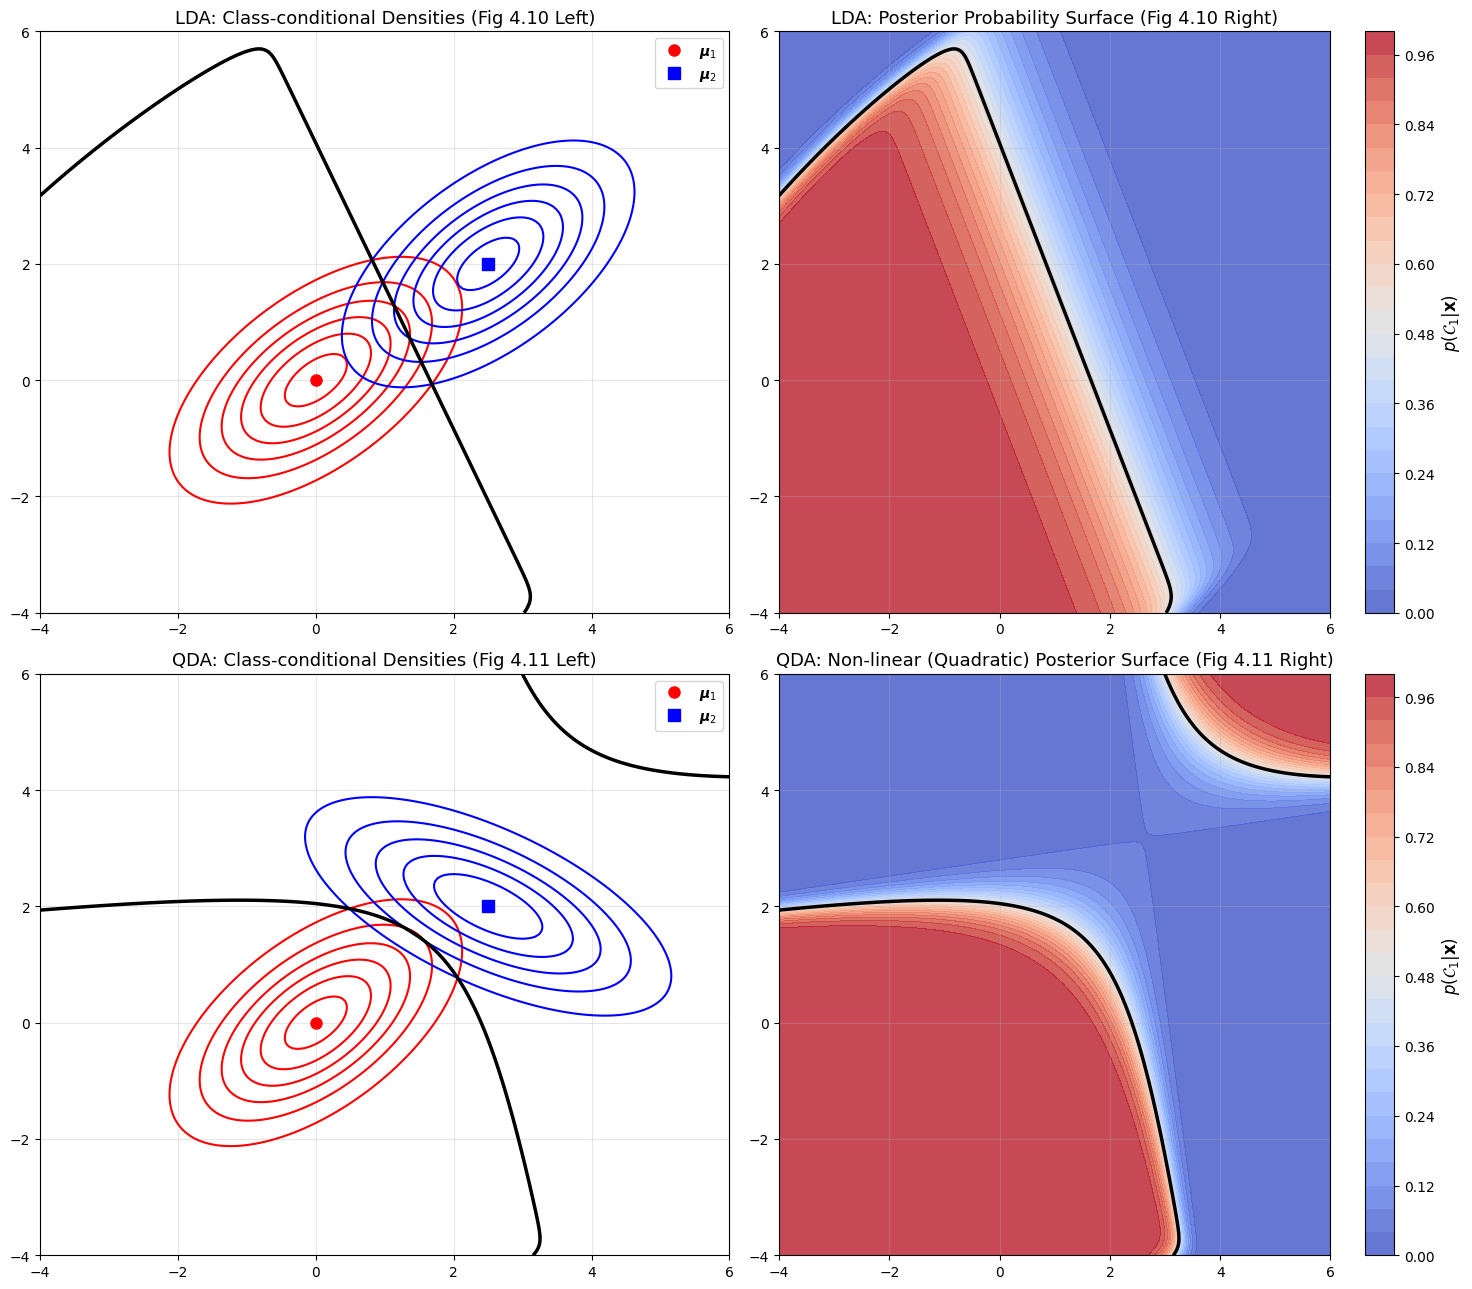

In [2]:
# PRML Figure 4.10 (共通共分散 LDA) と Figure 4.11 (個別共分散 QDA) の完全再現
import scipy.stats as stats

fig, axes = plt.subplots(2, 2, figsize=(15, 13))

x_grid = np.linspace(-4, 6, 200)
y_grid = np.linspace(-4, 6, 200)
Xg, Yg = np.meshgrid(x_grid, y_grid)
pos = np.dstack((Xg, Yg))

# ----------------- 1. LDA (Figure 4.10) -----------------
mu1_lda = np.array([0.0, 0.0])
mu2_lda = np.array([2.5, 2.0])
cov_lda = np.array([[1.2, 0.7], [0.7, 1.2]])

p1_lda = stats.multivariate_normal(mu1_lda, cov_lda).pdf(pos)
p2_lda = stats.multivariate_normal(mu2_lda, cov_lda).pdf(pos)

# 事後確率 p(C1|x) = p1 / (p1 + p2) (事前確率は等しいと仮定)
post1_lda = p1_lda / (p1_lda + p2_lda + 1e-12)

# クラス条件付き密度等高線
axes[0, 0].contour(Xg, Yg, p1_lda, levels=6, colors='red')
axes[0, 0].contour(Xg, Yg, p2_lda, levels=6, colors='blue')
axes[0, 0].contour(Xg, Yg, post1_lda, levels=[0.5], colors='black', linewidths=2.5)
axes[0, 0].plot(mu1_lda[0], mu1_lda[1], 'ro', markersize=8, label=r'$\boldsymbol{\mu}_1$')
axes[0, 0].plot(mu2_lda[0], mu2_lda[1], 'bs', markersize=8, label=r'$\boldsymbol{\mu}_2$')
axes[0, 0].set_title('LDA: Class-conditional Densities (Fig 4.10 Left)', fontsize=13)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 事後確率サーフェス
c_lda = axes[0, 1].contourf(Xg, Yg, post1_lda, levels=30, cmap='coolwarm', alpha=0.8)
axes[0, 1].contour(Xg, Yg, post1_lda, levels=[0.5], colors='black', linewidths=2.5)
fig.colorbar(c_lda, ax=axes[0, 1], label=r'$p(\mathcal{C}_1|\mathbf{x})$')
axes[0, 1].set_title('LDA: Posterior Probability Surface (Fig 4.10 Right)', fontsize=13)
axes[0, 1].grid(True, alpha=0.3)

# ----------------- 2. QDA (Figure 4.11) -----------------
mu1_qda = np.array([0.0, 0.0])
mu2_qda = np.array([2.5, 2.0])
cov1_qda = np.array([[1.2, 0.7], [0.7, 1.2]])
cov2_qda = np.array([[2.0, -0.9], [-0.9, 1.0]]) # 異なる共分散

p1_qda = stats.multivariate_normal(mu1_qda, cov1_qda).pdf(pos)
p2_qda = stats.multivariate_normal(mu2_qda, cov2_qda).pdf(pos)
post1_qda = p1_qda / (p1_qda + p2_qda + 1e-12)

axes[1, 0].contour(Xg, Yg, p1_qda, levels=6, colors='red')
axes[1, 0].contour(Xg, Yg, p2_qda, levels=6, colors='blue')
axes[1, 0].contour(Xg, Yg, post1_qda, levels=[0.5], colors='black', linewidths=2.5)
axes[1, 0].plot(mu1_qda[0], mu1_qda[1], 'ro', markersize=8, label=r'$\boldsymbol{\mu}_1$')
axes[1, 0].plot(mu2_qda[0], mu2_qda[1], 'bs', markersize=8, label=r'$\boldsymbol{\mu}_2$')
axes[1, 0].set_title('QDA: Class-conditional Densities (Fig 4.11 Left)', fontsize=13)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

c_qda = axes[1, 1].contourf(Xg, Yg, post1_qda, levels=30, cmap='coolwarm', alpha=0.8)
axes[1, 1].contour(Xg, Yg, post1_qda, levels=[0.5], colors='black', linewidths=2.5)
fig.colorbar(c_qda, ax=axes[1, 1], label=r'$p(\mathcal{C}_1|\mathbf{x})$')
axes[1, 1].set_title('QDA: Non-linear (Quadratic) Posterior Surface (Fig 4.11 Right)', fontsize=13)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig4_10_11_lda_qda.png')
plt.show()

## 4.2.3 離散特徴（ナイーブベイズ）と 4.2.4 指数型分布族

### ナイーブベイズモデル (Naive Bayes)
入力特徴が2値 $x_i \in \{0, 1\}$ であり、クラス所与の下で互いに条件付き独立であると仮定します：
$$ p(\mathbf{x} | \mathcal{C}_k) = \prod_{i=1}^D \mu_{ki}^{x_i} (1 - \mu_{ki})^{1 - x_i} $$
この対数オッズ比 $a(\mathbf{x})$ を計算すると：
$$ a(\mathbf{x}) = \ln \frac{p(\mathbf{x}|\mathcal{C}_1)p(\mathcal{C}_1)}{p(\mathbf{x}|\mathcal{C}_2)p(\mathcal{C}_2)} = \sum_{i=1}^D \left\{ x_i \ln \frac{\mu_{1i}}{\mu_{2i}} + (1 - x_i) \ln \frac{1 - \mu_{1i}}{1 - \mu_{2i}} \right\} + \ln \frac{p(\mathcal{C}_1)}{p(\mathcal{C}_2)} $$
これは $x_i$ について整理すると $a(\mathbf{x}) = \sum_i w_i x_i + w_0$ となり、**厳密に線形モデル**となります！

### 指数型分布族一般 (Exponential Family)
クラス条件付き分布が共通のスケーリングパラメータを持つ指数型分布族
$$ p(\mathbf{x} | \boldsymbol{\theta}_k, s) = \frac{1}{s} h\left(\frac{\mathbf{x}}{s}\right) g(\boldsymbol{\theta}_k) \exp\left\{ \frac{1}{s} \boldsymbol{\theta}_k^T \mathbf{u}(\mathbf{x}) \right\} $$
に従うとき、事後対数オッズは
$$ a(\mathbf{x}) = \frac{1}{s}(\boldsymbol{\theta}_1 - \boldsymbol{\theta}_2)^T \mathbf{u}(\mathbf{x}) + \ln \frac{g(\boldsymbol{\theta}_1)}{g(\boldsymbol{\theta}_2)} + \ln \frac{p(\mathcal{C}_1)}{p(\mathcal{C}_2)} $$
となり、$\mathbf{u}(\mathbf{x}) = \mathbf{x}$ のとき常に線形モデルが得られます。